In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


In [2]:
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [3]:
tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)

acc_tree_train = accuracy_score(y_train, tree.predict(X_train))
acc_tree_test = accuracy_score(y_test, tree.predict(X_test))

print("Decision Tree Train:", acc_tree_train)
print("Decision Tree Test :", acc_tree_test)

Decision Tree Train: 1.0
Decision Tree Test : 0.9473684210526315


In [4]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

acc_rf_train = accuracy_score(y_train, rf.predict(X_train))
acc_rf_test = accuracy_score(y_test, rf.predict(X_test))

print("Random Forest Train:", acc_rf_train)
print("Random Forest Test :", acc_rf_test)

Random Forest Train: 1.0
Random Forest Test : 0.9649122807017544


In [5]:
## Tabel Perbandingan
comparison_table = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest"],
    "Train Accuracy": [acc_tree_train, acc_rf_train],
    "Test Accuracy": [acc_tree_test, acc_rf_test]
})

comparison_table

,Model,Train Accuracy,Test Accuracy
0,Decision Tree,1.0,0.947368
1,Random Forest,1.0,0.964912


In [6]:
## Bagian B – Feature Importance
## Mengambil Feature Importance
importances = rf.feature_importances_

feat_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print(feat_importance.head(10))

                 Feature  Importance
23            worst area    0.153892
27  worst concave points    0.144663
7    mean concave points    0.106210
20          worst radius    0.077987
6         mean concavity    0.068001
22       worst perimeter    0.067115
2         mean perimeter    0.053270
0            mean radius    0.048703
3              mean area    0.047555
26       worst concavity    0.031802


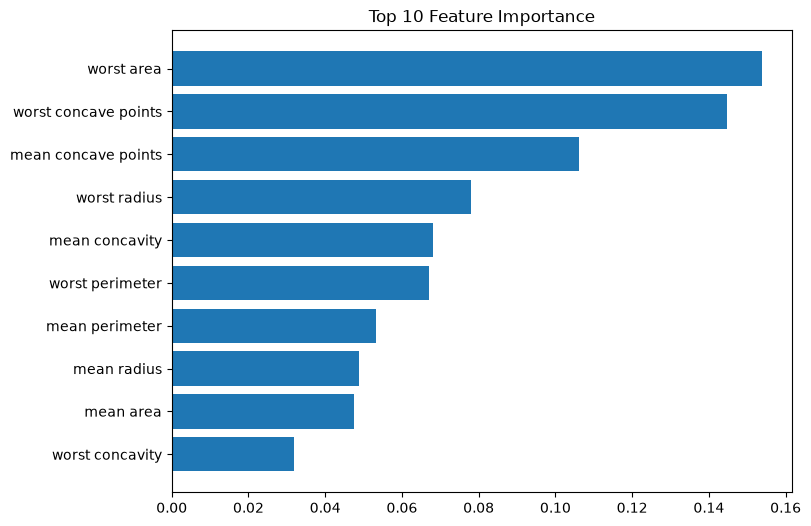

In [7]:
## Visualisasi
plt.figure(figsize=(8,6))
plt.barh(feat_importance["Feature"][:10],
         feat_importance["Importance"][:10])
plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importance")
plt.show()

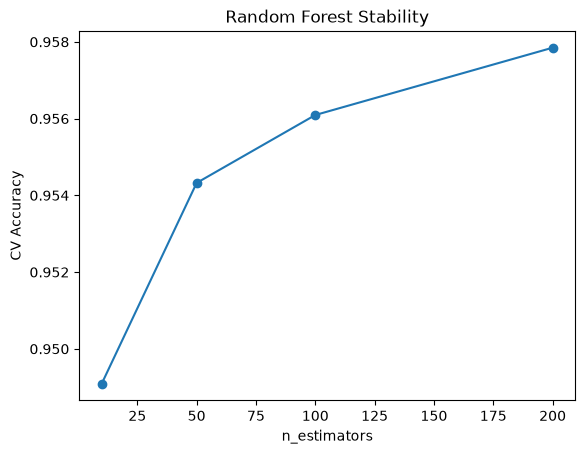

In [8]:
## Bagian C – Stability Test
## Uji n_estimators
estimators = [10, 50, 100, 200]
rf_scores = []

for n in estimators:
    model = RandomForestClassifier(n_estimators=n, random_state=42)
    score = cross_val_score(model, X, y, cv=5).mean()
    rf_scores.append(score)

plt.plot(estimators, rf_scores, marker='o')
plt.xlabel("n_estimators")
plt.ylabel("CV Accuracy")
plt.title("Random Forest Stability")
plt.show()


In [9]:
## Bagian D – PCA + Random Forest
## PCA dan Random Forest
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=10)
X_pca = pca.fit_transform(X_scaled)

rf_pca = RandomForestClassifier(n_estimators=100, random_state=42)
score_rf_pca = cross_val_score(rf_pca, X_pca, y, cv=5).mean()

score_rf = cross_val_score(rf, X, y, cv=5).mean()

print("RF tanpa PCA:", score_rf)
print("RF dengan PCA:", score_rf_pca)


RF tanpa PCA: 0.9560937742586555
RF dengan PCA: 0.9507529886663562


In [10]:
## TUGAS INDIVIDU ##
# Uji max_depth Berbeda pada Random Forest
depths = [3, 5, 10, 15, None]

depth_scores = []

for d in depths:

    model = RandomForestClassifier(
        n_estimators=100,
        max_depth=d,
        random_state=42
    )

    score = cross_val_score(
        model,
        X,
        y,
        cv=5
    ).mean()

    depth_scores.append(score)

depth_table = pd.DataFrame({
    "Max Depth": depths,
    "CV Accuracy": depth_scores
})

depth_table

,Max Depth,CV Accuracy
0,3.0,0.954324
1,5.0,0.959618
2,10.0,0.956094
3,15.0,0.956094
4,NaN,0.956094


In [11]:
## Uji Parameter max_features
max_features_values = [
    "sqrt",
    "log2",
    None
]

feature_scores = []

for mf in max_features_values:

    model = RandomForestClassifier(
        n_estimators=100,
        max_features=mf,
        random_state=42
    )

    score = cross_val_score(
        model,
        X,
        y,
        cv=5
    ).mean()

    feature_scores.append(score)

max_feature_table = pd.DataFrame({
    "max_features": max_features_values,
    "CV Accuracy": feature_scores
})

max_feature_table

,max_features,CV Accuracy
0,sqrt,0.956094
1,log2,0.959603
2,NaN,0.956140


In [12]:
## Uji Parameter min_samples_leaf
leaf_values = [1, 2, 4, 8]

leaf_scores = []

for leaf in leaf_values:

    model = RandomForestClassifier(
        n_estimators=100,
        min_samples_leaf=leaf,
        random_state=42
    )

    score = cross_val_score(
        model,
        X,
        y,
        cv=5
    ).mean()

    leaf_scores.append(score)

leaf_table = pd.DataFrame({
    "min_samples_leaf": leaf_values,
    "CV Accuracy": leaf_scores
})

leaf_table

,min_samples_leaf,CV Accuracy
0,1,0.956094
1,2,0.957848
2,4,0.959618
3,8,0.954339


In [13]:
## Perbandingan dengan Logistic Regression
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(
    max_iter=5000
)

score_log = cross_val_score(
    log_model,
    X,
    y,
    cv=5
).mean()

score_rf = cross_val_score(
    rf,
    X,
    y,
    cv=5
).mean()

comparison_model = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "CV Accuracy": [
        score_log,
        score_rf
    ]
})

comparison_model

,Model,CV Accuracy
0,Logistic Regression,0.950800
1,Random Forest,0.956094


In [14]:
## Tabel Eksperimen
experiment_table = pd.DataFrame({
    "Eksperimen": [
        "Random Forest Default",
        "RF max_depth terbaik",
        "RF max_features terbaik",
        "RF min_samples_leaf terbaik",
        "Logistic Regression"
    ],
    "CV Accuracy": [
        score_rf,
        max(depth_scores),
        max(feature_scores),
        max(leaf_scores),
        score_log
    ]
})

experiment_table

,Eksperimen,CV Accuracy
0,Random Forest Default,0.956094
1,RF max_depth terbaik,0.959618
2,RF max_features terbaik,0.959603
3,RF min_samples_leaf terbaik,0.959618
4,Logistic Regression,0.950800
